In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pvlib
import pandas as pd
from scipy.optimize import newton

In [ ]:
# input instructions:
# df is a dataframe containing columns 'Wind Speed','Temperature', 'DNI', 'DHI', and 'GHI' with solar irradiance data, with a datetime index corresponding to the timestamps of the data
# lat and long are the latitude and longitude of the collector location
# hemisphere is either 'northern' or 'southern' to determine surface azimuth for solar calculations
# T_amb is a pandas Series containing ambient temperature data corresponding to the timestamps in 'times'
def evacuated_tube_collector(Ac,beta,Cb,Cp,D,Di,epsilon_g,epsilon_p,k,k_air,m_dot,nu,nu_air,rho,tau,alpha,T_water,t,W,lat,long,df,hemisphere):    
    
    sig=5.67e-8 # Stefan-Boltzmann constant

    T_fi=T_water # inlet temperature
    T_fo=T_fi+3 # estimate temperature grows by 3 degrees Kelvin

    # extract values from df
    T_amb=df['Temperature']+273.15 # convert ambient temperature from Celsius to Kelvin
    T_g=df['Temperature']+273.15 # assume pipe temperature is approximately ambient
    V_wind=df['Wind Speed'] # extract wind speed data

    # fluid pipe fluid dynamics
    Re_int=4*m_dot/(np.pi*Di*nu) # fluid pipe Reynolds number
    Pr_int=rho*nu*Cp/k # fluid pipe Prandtl number
    f=(0.79*np.log(Re_int)-1.64)**-2 # fluid pipe friction factor
    Nu=(f/8)*(Re_int-1000)*Pr_int/(1+12.7*np.sqrt(f/8)*(Pr_int**(2/3)-1)) # fluid pipe Nusselt number, using Gnielinski correlation -- assume 3e3 < Re < 5e6 and 0.5 < Pr < 2000
    h_fi=Nu*k/Di # fluid pipe convective heat transfer coefficient

    # external heat transfer
    Re_ext=D*V_wind/nu_air # Reynolds number for external convection
    Pr_air=0.7 # Prandtl number for air at room temperature
    Nu_ext=0.3+0.62*Re_ext**(1/2)*Pr_air**(1/3)/(1+(0.4/Pr_air)**(2/3))**(1/4)*(1+(Re_ext/282000)**(5/8))**(4/5) # Nusselt number for external convection, using the Churchill-Bernstein correlation for flow over a cylinder
    h_ext=k_air*Nu_ext/D # external convective heat transfer coefficient

    T_pm=(T_fo+T_fi)/2 # mean fluid temperature
    hr_pc=sig*(1/(1/epsilon_g+1/epsilon_p-1))*(T_pm**2-T_g**2)*(T_pm+T_g) # radiative heat transfer coefficient between fluid and pipe
    hr_ca=sig*epsilon_g*(T_g**2-T_amb**2)*(T_g+T_amb) # radiative heat transfer coefficient between pipe and air

    # overall loss coefficient
    Ul=(1/hr_pc+1/(h_ext+hr_ca))**-1

    # fin and collector efficiency
    m=np.sqrt(Ul/(k*t)) # fin parameter
    F=np.tanh(m*(W-D)/2)/(m*(W-D)/2) # fin efficiency
    F_prime=(1/Ul)/((1/(Ul*(D+(W-D)*F)))+1/Cb+1/(np.pi*Di*h_fi)) # collector efficiency factor
    Fr=m_dot*Cp/(Ac*Ul)*(1-np.exp(-Ac*Ul*F_prime/(m_dot*Cp))) # heat removal factor

    # solar data
    times=df.index # extract timestamps from dataframe index
    solpos=pvlib.solarposition.get_solarposition(times, lat, long) # get solar position data
    if hemisphere=='southern': # determine surface azimuth based on hemisphere
        surface_azimuth=0
    elif hemisphere=='northern':
        surface_azimuth=180
    it_data=pvlib.irradiance.get_total_irradiance( # calculate plane of array irradiance data
        surface_tilt=beta,
        surface_azimuth=surface_azimuth,
        dni=df['DNI'],
        dhi=df['DHI'],
        ghi=df['GHI'],
        solar_zenith=solpos['zenith'],
        solar_azimuth=solpos['azimuth']
    )
    It=it_data['poa_global'] # total plane of array irradiance
    
   # useful heat gain calculation
    Qu=Ac*Fr*(It*tau*alpha-Ul*(T_fi-T_amb)) # useful heat gain
    Qu=Qu.clip(lower=0) # ensure useful heat gain is not negative
    return Qu, Ul

# input instructions:
# N is an integer corresponding to the number of tubes in the collector
# N_parallel_rows is an integer corresponding to the number of rows of tubes connected in parallel
# N/N_parallel_rows must be an integer value
# Qu_initial is a list of useful heat gain values for initial tubes, calculated from the evacuated_tube_collector function
# Note: this function looks at simple configurations. You must run multiple iterations of this function to analyze more complex configurations
def config(Qu_initial,Ul_initial,T_in,N,N_parallel_rows,Ac,beta,Cb,Cp,D,Di,epsilon_g,epsilon_p,k,k_air,m_dot,nu,nu_air,rho,tau,alpha,t,W,lat,long,df,hemisphere):
    m_dot_per_row=m_dot/N_parallel_rows
    N_each_row=range(1,N//N_parallel_rows+1)
    T_out=0
    T_out_collector={}
    Qu_collector={}
    Ul_collector={}
    T_in_i=T_in
    Qu_i=Qu_initial
    Ul_i=Ul_initial
    for i in N_each_row:
        if i==1:
            Qu_i=Qu_initial
            Ul_i=Ul_initial
        else:
            Qu_i,Ul_i=evacuated_tube_collector(Ac,beta,Cb,Cp,D,Di,epsilon_g,epsilon_p,k,k_air,m_dot_per_row,nu,nu_air,rho,tau,alpha,T_in_i,t,W,lat,long,df,hemisphere) # set T_water to T_in_i
        T_out_i=T_in_i+Qu_i/(m_dot_per_row*Cp) # calculate outlet temperature for each tube in the row
        T_out_collector[i]=T_out_i # store outlet temperature for each tube in the row
        Ul_collector[i]=Ul_i # store overall loss coefficient for each tube in the row
        T_in_i=T_out_i # outlet of one tube becomes inlet for the next tube in series
        Qu_collector[i]=Qu_i # store useful heat gain for each tube in the row
    T_out=T_out_i # final outlet temperature
    Qu_total=sum(Qu_collector.values())*N_parallel_rows # total useful heat gain
    return Qu_total,T_out,T_out_collector,Qu_collector,Ul_collector

# input instructions:
# almost identical to evacuated_tube_collector() except T_out replaces Ac
def area(T_out,beta,Cb,Cp,D,Di,epsilon_g,epsilon_p,k,k_air,m_dot,nu,nu_air,rho,tau,alpha,T_water,t,W,lat,long,df,hemisphere):    
    
    sig=5.67e-8 # Stefan-Boltzmann constant

    T_fi=T_water # inlet temperature
    T_fo=T_fi+3 # estimate temperature grows by 3 degrees Kelvin

    # extract values from df
    T_amb=df['Temperature']+273.15 # convert ambient temperature from Celsius to Kelvin
    T_g=df['Temperature']+273.15 # assume pipe temperature is approximately ambient
    V_wind=df['Wind Speed'] # extract wind speed data

    # fluid pipe fluid dynamics
    Re_int=4*m_dot/(np.pi*Di*nu) # fluid pipe Reynolds number
    Pr_int=rho*nu*Cp/k # fluid pipe Prandtl number
    f=(0.79*np.log(Re_int)-1.64)**-2 # fluid pipe friction factor
    Nu=(f/8)*(Re_int-1000)*Pr_int/(1+12.7*np.sqrt(f/8)*(Pr_int**(2/3)-1)) # fluid pipe Nusselt number, using Gnielinski correlation -- assume 3e3 < Re < 5e6 and 0.5 < Pr < 2000
    h_fi=Nu*k/Di # fluid pipe convective heat transfer coefficient

    # external heat transfer
    Re_ext=D*V_wind/nu_air # Reynolds number for external convection
    Pr_air=0.7 # Prandtl number for air at room temperature
    Nu_ext=0.3+0.62*Re_ext**(1/2)*Pr_air**(1/3)/(1+(0.4/Pr_air)**(2/3))**(1/4)*(1+(Re_ext/282000)**(5/8))**(4/5) # Nusselt number for external convection, using the Churchill-Bernstein correlation for flow over a cylinder
    h_ext=k_air*Nu_ext/D # external convective heat transfer coefficient

    T_pm=(T_fo+T_fi)/2 # mean fluid temperature
    hr_pc=sig*(1/(1/epsilon_g+1/epsilon_p-1))*(T_pm**2-T_g**2)*(T_pm+T_g) # radiative heat transfer coefficient between fluid and pipe
    hr_ca=sig*epsilon_g*(T_g**2-T_amb**2)*(T_g+T_amb) # radiative heat transfer coefficient between pipe and air

    # overall loss coefficient
    Ul=(1/hr_pc+1/(h_ext+hr_ca))**-1

    # fin and collector efficiency
    m=np.sqrt(Ul/(k*t)) # fin parameter
    F=np.tanh(m*(W-D)/2)/(m*(W-D)/2) # fin efficiency
    F_prime=(1/Ul)/((1/(Ul*(D+(W-D)*F)))+1/Cb+1/(np.pi*Di*h_fi)) # collector efficiency factor

    # solar data
    times=df.index # extract timestamps from dataframe index
    solpos=pvlib.solarposition.get_solarposition(times, lat, long) # get solar position data
    if hemisphere=='southern': # determine surface azimuth based on hemisphere
        surface_azimuth=0
    elif hemisphere=='northern':
        surface_azimuth=180
    it_data=pvlib.irradiance.get_total_irradiance( # calculate plane of array irradiance data
        surface_tilt=beta,
        surface_azimuth=surface_azimuth,
        dni=df['DNI'],
        dhi=df['DHI'],
        ghi=df['GHI'],
        solar_zenith=solpos['zenith'],
        solar_azimuth=solpos['azimuth']
    )
    It=it_data['poa_global'] # total plane of array irradiance
    
    # conservative design point: size for the 20th percentile of daylight irradiance
    # and the Ul/F_prime that correspond to that SAME timestamp (not independently picked)
    threshold = It > It[It>0].quantile(0.20)
    worst_idx = It[threshold].idxmin()  # timestamp of worst daylight irradiance

    It_val = It[worst_idx]
    Ul_val = Ul[worst_idx]
    F_prime_val = F_prime[worst_idx]
    T_amb_val = T_amb[worst_idx]
   
    Qu_target = (T_out - T_water) * (m_dot * Cp)

    def residual(Ac):
        Fr = m_dot*Cp/(Ac*Ul_val)*(1-np.exp(-Ac*Ul_val*F_prime_val/(m_dot*Cp)))
        Qu = Ac*Fr*(It_val*tau*alpha - Ul_val*(T_fi - T_amb_val))
        return Qu - Qu_target

    Ac_solution = newton(residual, x0=0.001)  # x0 is your initial guess for Ac
    return Ac_solution



/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


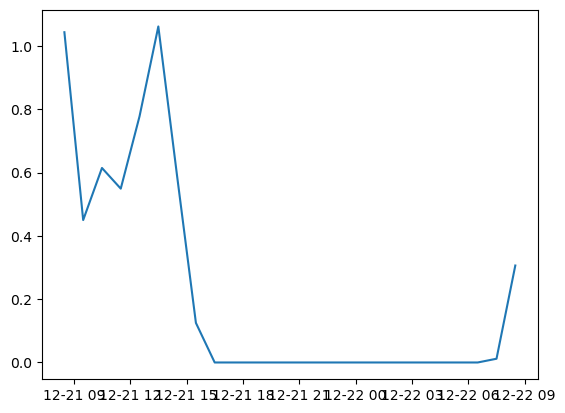

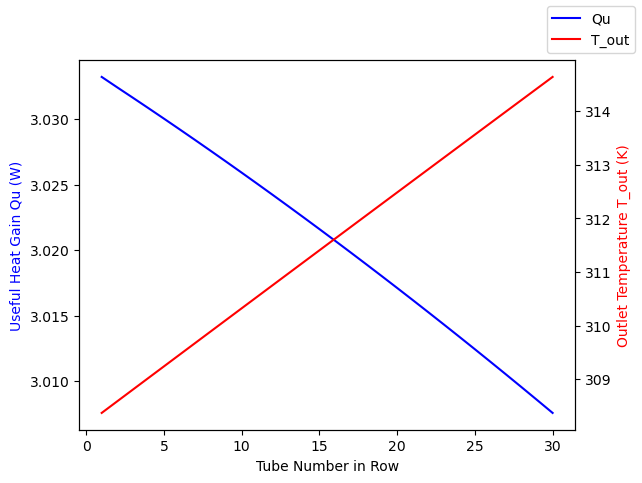

In [16]:
# test case
df=pd.read_csv("/Users/shoon/Desktop/ESL/SAM Downloaded Weather Files/ashburn_va_39.0523_-77.4827_nsrdb-GOES-tmy-v4-0-0_60_tmy.csv", skiprows=2) # ashburn tmy data
df['Year']=2026 # set year to 2026 to deal with tmy year handling
df['times']=pd.to_datetime(df[['Year','Month','Day','Hour','Minute']])
df=df.set_index('times')
df.index=df.index.tz_localize('Etc/GMT+5') # localize to correct timezone
Qu_test,Ul_test=evacuated_tube_collector(Ac=0.08,beta=30,Cb=0.9,Cp=4186,D=0.05,Di=0.04,epsilon_g=0.9,epsilon_p=0.8,k=205,k_air=0.025,m_dot=0.01,nu=1e-6,nu_air=1.5e-5,rho=1000,tau=0.9,alpha=0.9,T_water=308.15,t=0.00012,W=0.06,lat=39.05,long=-77.5,df=df,hemisphere='northern')
plt.figure()
plt.plot(Qu_test['2026-12-21 08:30:00-05:00':'2026-12-22 08:30:00-05:00'])
# continue with config
config_test=config(Qu_initial=Qu_test,Ul_initial=Ul_test,T_in=308.15,N=90,N_parallel_rows=3,Ac=0.08,beta=30,Cb=0.9,Cp=4186,D=0.05,Di=0.04,epsilon_g=0.9,epsilon_p=0.8,k=205,k_air=0.025,m_dot=0.01,nu=1e-6,nu_air=1.5e-5,rho=1000,tau=0.9,alpha=0.9,t=0.00012,W=0.06,lat=39.05,long=-77.5,df=df,hemisphere='northern')
# config_test[0] returns Qu_total as a pandas series
# config_test[1] returns T_out as a pandas series
# config_test[2] returns T_out_collector as a dictionary of series per tube
# config_test[3] returns Qu_collector as a dictionary of series per tube
# config_test[4] returns Ul_collector as a dictionary of series per tube
x_vals=range(1,31)
y_vals=[config_test[3][i]['2026-06-21 14:30:00-05:00'] for i in x_vals]
y_vals_2=[config_test[2][i]['2026-06-21 14:30:00-05:00'] for i in x_vals]
fig,ax1=plt.subplots()
ax1.plot(x_vals,y_vals,color='blue',label='Qu')
ax1.set_ylabel('Useful Heat Gain Qu (W)',color='blue')
ax1.set_xlabel('Tube Number in Row')
ax2=ax1.twinx()
ax2.plot(x_vals,y_vals_2,color='red',label='T_out')
ax2.set_ylabel('Outlet Temperature T_out (K)',color='red')
fig.legend()
plt.show()


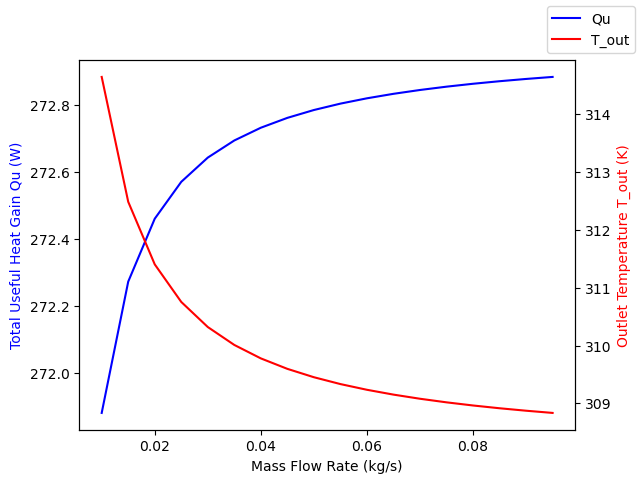

In [6]:
# mass flow test
m_dot_test=np.arange(0.01, 0.1, 0.005)
Qu_total_mdottest={}
T_out_mdottest={}
for i in m_dot_test:
    Qu_mdottest,Ul_mdottest=evacuated_tube_collector(Ac=0.08,beta=30,Cb=0.9,Cp=4186,D=0.05,Di=0.04,epsilon_g=0.9,epsilon_p=0.8,k=205,k_air=0.025,m_dot=i,nu=1e-6,nu_air=1.5e-5,rho=1000,tau=0.9,alpha=0.9,T_water=308.15,t=0.00012,W=0.06,lat=39.05,long=-77.5,df=df,hemisphere='northern')
    Qu_total_mdottest[i],T_out_mdottest[i]=config(Qu_initial=Qu_test,Ul_initial=Ul_test,T_in=308.15,N=90,N_parallel_rows=3,Ac=0.08,beta=30,Cb=0.9,Cp=4186,D=0.05,Di=0.04,epsilon_g=0.9,epsilon_p=0.8,k=205,k_air=0.025,m_dot=i,nu=1e-6,nu_air=1.5e-5,rho=1000,tau=0.9,alpha=0.9,t=0.00012,W=0.06,lat=39.05,long=-77.5,df=df,hemisphere='northern')[0:2]
y_vals_m=[Qu_total_mdottest[i]['2026-06-21 14:30:00-05:00'] for i in m_dot_test]
y_vals_2_m=[T_out_mdottest[i]['2026-06-21 14:30:00-05:00'] for i in m_dot_test]
fig_m,ax1_m=plt.subplots()
ax1_m.plot(m_dot_test,y_vals_m,color='blue',label='Qu')
ax1_m.set_ylabel('Total Useful Heat Gain Qu (W)',color='blue')
ax1_m.set_xlabel('Mass Flow Rate (kg/s)')
ax2_m=ax1_m.twinx()
ax2_m.plot(m_dot_test,y_vals_2_m,color='red',label='T_out')
ax2_m.set_ylabel('Outlet Temperature T_out (K)',color='red')
fig_m.legend()
plt.show()

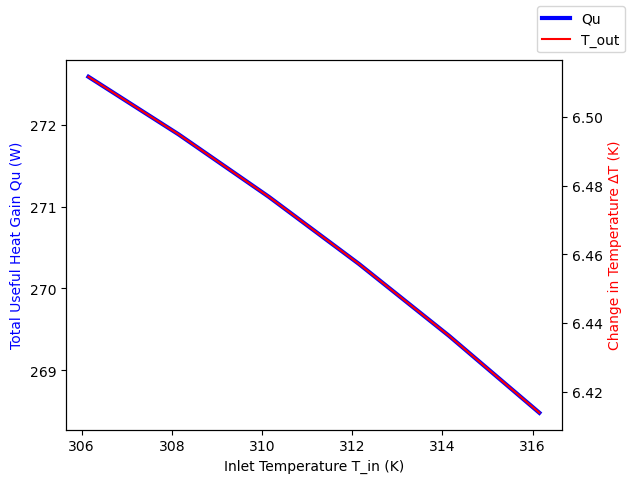

In [7]:
# T_in test
T_in_test=np.arange(298.15, 318.15, 2)
Qu_total_T_in_test={}
T_out_T_in_test={}
for i in T_in_test:
    Qu_T_in_test,Ul_T_in_test=evacuated_tube_collector(Ac=0.08,beta=30,Cb=0.9,Cp=4186,D=0.05,Di=0.04,epsilon_g=0.9,epsilon_p=0.8,k=205,k_air=0.025,m_dot=0.01,nu=1e-6,nu_air=1.5e-5,rho=1000,tau=0.9,alpha=0.9,T_water=i,t=0.00012,W=0.06,lat=39.05,long=-77.5,df=df,hemisphere='northern')
    Qu_total_T_in_test[i],T_out_T_in_test[i]=config(Qu_initial=Qu_T_in_test,Ul_initial=Ul_T_in_test,T_in=i,N=90,N_parallel_rows=3,Ac=0.08,beta=30,Cb=0.9,Cp=4186,D=0.05,Di=0.04,epsilon_g=0.9,epsilon_p=0.8,k=205,k_air=0.025,m_dot=0.01,nu=1e-6,nu_air=1.5e-5,rho=1000,tau=0.9,alpha=0.9,t=0.00012,W=0.06,lat=39.05,long=-77.5,df=df,hemisphere='northern')[0:2]
y_vals_T_in=[Qu_total_T_in_test[i]['2026-06-21 14:30:00-05:00'] for i in T_in_test]
y_vals_2_T_in=[T_out_T_in_test[i]['2026-06-21 14:30:00-05:00']-i for i in T_in_test]
fig_T_in,ax1_T_in=plt.subplots()
ax1_T_in.plot(T_in_test,y_vals_T_in,color='blue',label='Qu',lw=3)
ax1_T_in.set_ylabel('Total Useful Heat Gain Qu (W)',color='blue')
ax1_T_in.set_xlabel('Inlet Temperature T_in (K)')
ax2_T_in=ax1_T_in.twinx()
ax2_T_in.plot(T_in_test,y_vals_2_T_in,color='red',label='T_out')
ax2_T_in.set_ylabel('Change in Temperature ∆T (K)',color='red')
fig_T_in.legend()
plt.show()
# same slope!

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered

75.98076211353317
75.98076211353317
75.98076211353317
75.98076211353317
75.98076211353317
75.98076211353317
75.98076211353317
75.98076211353317
75.98076211353317
75.98076211353317


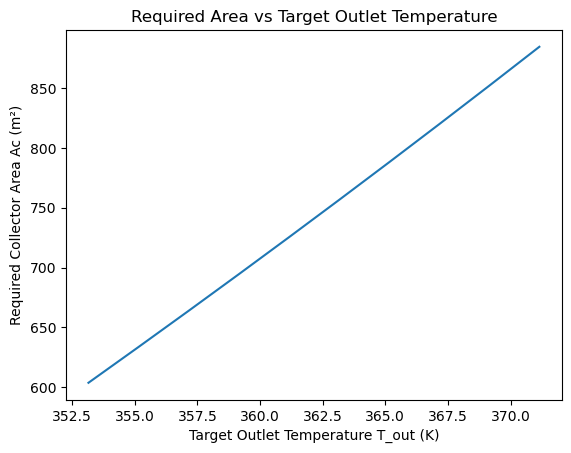

In [21]:
# area test
T_out_test=np.arange(353.15,373.15,2)
A_test ={}

for i in T_out_test:
    A_test[i]=area(T_out=i,beta=30,Cb=0.9,Cp=4186,D=0.05,Di=0.04,epsilon_g=0.9,epsilon_p=0.8,k=205,k_air=0.025,m_dot=0.01,nu=1e-6,nu_air=1.5e-5,rho=1000,tau=0.9,alpha=0.9,T_water=308.15,t=0.00012,W=0.06,lat=39.05,long=-77.5,df=df,hemisphere='northern')
y_vals = [A_test[i] for i in T_out_test]

plt.plot(T_out_test, y_vals)
plt.xlabel('Target Outlet Temperature T_out (K)')
plt.ylabel('Required Collector Area Ac (m²)')
plt.title('Required Area vs Target Outlet Temperature')
plt.show()